# IAPR: Final Project ‒ UNO Game State Recovery


**Group ID:** 46

**Author 1 (sciper):** Lemonnier Théo (312284)  
**Author 2 (sciper):** Desnos Edgar (388960)   
**Author 3 (sciper):** Anthonin Duval (355584)

## Imports and Configurations

In [1]:
from pathlib import Path

from src.token_detection import generate_pipeline_figure

In [2]:
TRAIN_IMAGES_PATH = Path("./data/iapr-26-uno-vision-challenge/train_images")

## Card Detection (YOLO)

Card detections are returned as a list of CardDetection dataclass (src/detection.py) with the following fields:
 
    — the four corner points of the card (corner bbox rectangle), corner_crops 
    — 1 or 2 RGB 80×80 crops fed to the CNN
    — boolean mask of the pixels where the card color should be sampled 
    — (x, y) used for player-zone assignment
    — YOLO confidence score.

The YOLO backend (src/yolo_backend.py) wraps an Ultralytics YOLOv8s model trained to detect the card's corner symbol bbox, not the full card outline. It is fast and reliable on the noisy leafy background, where saturation thresholding tends to over-segment.

The fact that YOLO only returns the corner bbox is a problem for the color classifier, which needs to vote on a region containing the printed card color rather than the symbol itself. Sampling inside the corner bbox would mostly capture digits/icons and miss the card body. To solve this without running a second segmenter, the body mask is built as a ring around the corner bbox: an outer rectangle padded by 1.5× the bbox side, an inner rectangle padded by 0.2× the bbox side, the mask is the difference of the two. This carves out a band of pixels just outside the symbol corner, where the card body is guaranteed to be visible, while excluding the symbol and most of the background. The HSV color classifier then runs on this mask unchanged.

We reached a score of 86%.

## Color Filtering

Color classification is also fully classical (`src/color_classifier.py`, `src/detect_reference.py`). For each input image we compute five HSV masks : Yellow, Red, Blue, Green and Black, using hand-tuned ranges. Red wraps around the HSV hue cylinder, so it is built as the union of two separate ranges (low hue and high hue).

To label a card we restrict each color mask to the card's body mask returned by the segmenter, count the number of mask pixels that fall inside, and pick the color with the most votes. This is robust to the printed symbol pixels because they only account for a small fraction of the card body. The four returned labels are mapped to the submission alphabet `{r, g, b, y}`.

Two symbol classes (`wild` and `+4`) are color-agnostic by the rules of the game, so when the CNN predicts one of those we skip the color step entirely and emit the symbol on its own.

## Symbol Recognition with a CNN

Recognising the digits and action symbols (`0`–`9`, `+2`, `+4`, `wild`, `skip`, `reverse` — 15 classes total) is the part of the pipeline where a learned model clearly outperforms a classical approach, because of the visual variety of the symbols and of the printing/lighting conditions.

We trained a small VGG-style CNN (`hybric_detection_utils/train_uno.py`, class `UnoSymbolCNN`): four convolutional blocks with batch normalisation, global average pooling and a linear head, for about 4.8M parameters : well under the 12M cap of the competition. Inputs are 80x80 RGB crops normalised with the standard ImageNet mean/std. The training crops are generated by the same corner-extraction routine used at inference (`extract_corner_crops`), which guarantees that train and test distributions match.

At inference time (`src/card_labeler.predict_card`) we run the CNN on the two corner crops of each card (top-left and bottom-right corner indices). UNO cards repeat the same symbol in both corners, so we keep the prediction with the higher softmax confidence. The resulting symbol is then concatenated with the color label from the HSV pipeline (`submission_label` in `src/class_maps.py`) to form the final card string.

## Player Zone Assignment

Once all cards are detected, we still need to decide which card belongs to which player and which one is the center card. This is handled by `src/player_zones.py`.

The four player zones are not hard-coded in pixels but loaded from `data/jetons_et_backgrounds/backgrounds/bbox_player_position.csv`, which stores `(posx, posy, width, height)` for each player on the reference background. We convert those rectangles into **fractional coordinates** (relative to the reference image width and height) so the same zones can be reused on any image size : assignment then only depends on a card's centroid expressed as a fraction of the image.

The **center ROI** is derived geometrically from the four player zones: it spans horizontally between player 4's right edge and player 2's left edge, and vertically between player 3's bottom edge and player 1's top edge — i.e. the empty region in the middle of the table. If that computation ever degenerates (e.g. inconsistent CSV), we fall back to a centered 40%-60% rectangle.

The full assignment in `process_image_with_detections` works as follows:
1. `detect_center` keeps the unique detection whose centroid is inside the center ROI — if zero or more than one card falls there, we declare no center card (empty `center_card`).
2. All remaining detections are passed to `assign_hands`, which tests each centroid against the four player rectangles and groups detections by player.
3. Each per-player list is labelled by the CNN+color pipeline and joined with `;` into the final `player_X_cards` field; if a player has no card we emit `"EMPTY"`, matching the submission format.

## Background-Aware Segmentation

The same mean-saturation signal that decides which active-player token to look for is reused inside the classical card detector. In `src/classical_backend.py` the very first step calls `detect_background(image_bgr)`, which returns `"white"` or `"noisy"` based on the average saturation of the image. The result is passed straight to `segment_cards(image_bgr, background_kind=...)`, which then picks the appropriate saturation threshold (`15` for the white background, `30` for the noisy leafy one, see `src/segment_cards.py`).

This single, cheap, image-level statistic therefore drives two independent decisions:
1. **Card segmentation threshold** in the classical detection backend.
2. **Active-player token type** (yellow disc vs. black rectangle) in the token detector.

Keeping a single background-classification primitive shared between both subsystems avoids drift and ensures the pipeline reacts coherently to whichever scene type the image belongs to.

## Active Player Detection

To determine the active player, we implement a classical computer vision pipeline. This rule-based approach is chosen over deep learning because the active player tokens possess highly distinct, invariant shapes and colors compared to the standard game cards, making them computationally efficient to isolate.

### Background Classification

The dataset features two distinct environments, each utilizing a specific active player token:
- White Background: Employs a rectangular, black token.
- Leafy Background: Employs a circular, yellow token.

Because each token requires unique geometric and color filters, the pipeline first classifies the background by computing the mean saturation across the HSV color space of the entire image. Images with a mean saturation greater than $50$ are classified as leafy, while the remainder are classified as white.

### Token Localization Pipeline

Once the background and the target token is identified, the pipeline executes the following sequence:
1. Color Thresholding: The image is converted to the HSV color space and thresholded using predefined ranges to isolate pixels matching the target token's color profile (black or yellow).
2. Morphological Filtering: An opening operator removes small, isolated noise spikes (e.g., speckles on cards), followed by a closing operator to bridge micro-gaps and smooth the boundaries of the target blob masks.
3. Contour Filtering & Scoring: External contours are extracted. Candidate blobs are evaluated against known geometric priors of the token (area, circularity for the yellow token, aspect ratio and rectangularity for the black token). The highest-scoring candidate is selected.
4. Centroid Mapping: The center of mass (centroid) of the optimal contour is computed via image moments and mapped to the closest image quadrant to output the active player ID (1 to 4).

### Visual Pipeline Analysis

Below we illustrate the step-by-step intermediate transformations of our pipeline for both background modalities, proving the robustness of the HSV masks and morphological steps under varying conditions.

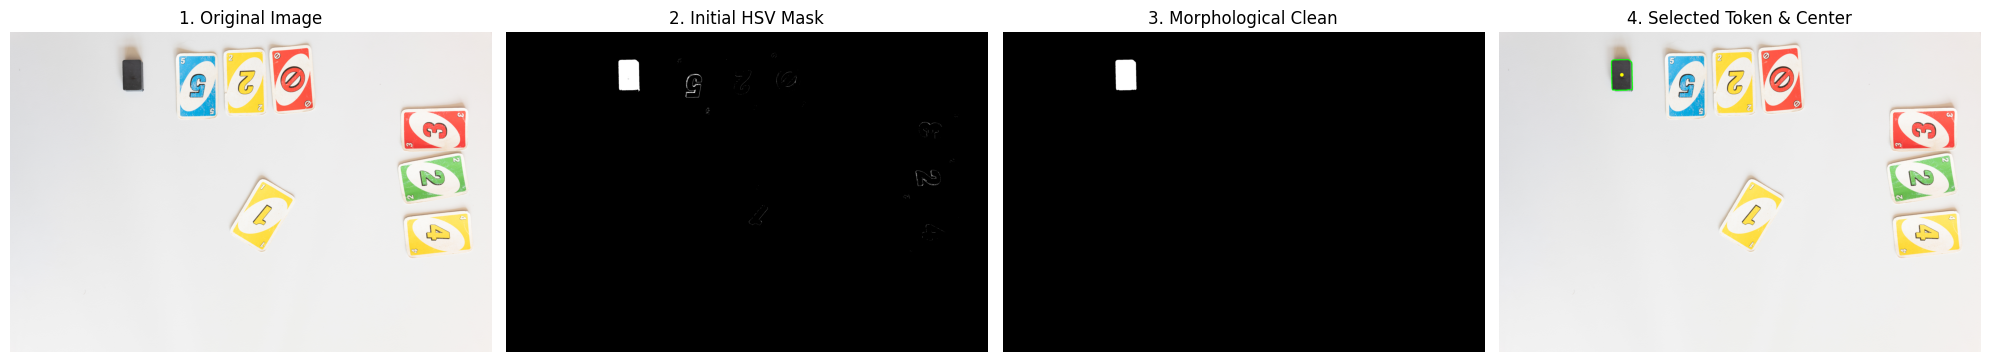

In [3]:
generate_pipeline_figure(TRAIN_IMAGES_PATH / "L1000770.jpg")

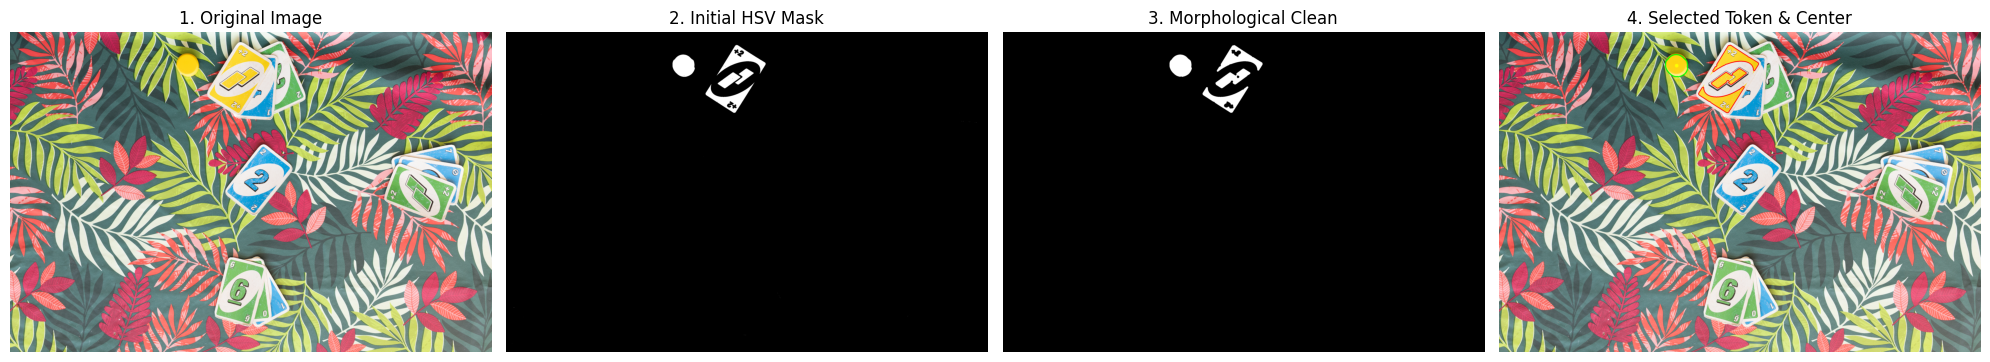

In [4]:
generate_pipeline_figure(TRAIN_IMAGES_PATH / "L1000973.jpg")